In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.svm import SVR

# Load 
df = pd.read_csv("/kaggle/input/datasets/prarthanap374/marketing-and-product-performance/marketing_and_product_performance.csv") 
df = df.dropna() 
X = df.select_dtypes(include=np.number).drop(columns=['Revenue_Generated']) 
y = df['Revenue_Generated'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
models = { "Linear": LinearRegression(), 
          "Random Forest": RandomForestRegressor(), 
          "SVM": SVR() } 
results = [] 
for name, model in models.items(): 
    model.fit(X_train, y_train)
    pred = model.predict(X_test) 
    results.append([ 
        name, 
        mean_absolute_error(y_test, pred), 
        np.sqrt(mean_squared_error(y_test, pred)), 
        r2_score(y_test, pred) 
    ])
df_table = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"]) 
df_table


,Model,MAE,RMSE,R2
0,Linear,24755.639879,28600.755023,-0.003157
1,Random Forest,25102.759496,29101.820619,-0.038614
2,SVM,24729.010782,28589.462750,-0.002365


In [7]:
df_table.to_csv('/kaggle/working/table_rq2.csv', index=False)
print("Table saved")


Table saved


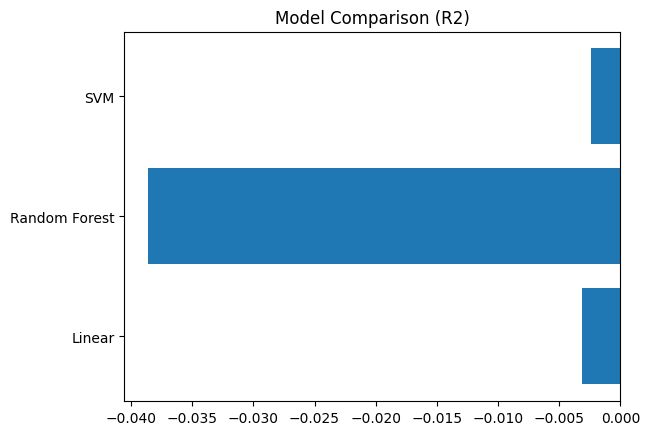

In [8]:
# Plot
plt.figure() 
plt.barh(df_table["Model"], df_table["R2"]) 
plt.title("Model Comparison (R2)") 
plt.savefig('/kaggle/working/figure_rq2.pdf') 
plt.show()